In [2]:
import torch
import torch_geometric
print(f"PyTorch version: {torch.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()}")

/Users/eugene/anaconda3/envs/gnn_fin/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.5.1
MPS available: True


In [3]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 1.1 MB/s  0:00:01 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 1.9 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]


In [4]:
!pip install numpy scikit-learn pandas matplotlib

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 1.9 MB/s  0:00:04 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 4.9 MB/s  0:00:01 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 7.4 MB/s  0:00:00 eta 0:00:01m
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 5.8 MB/s  0:00:03 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [matplotlib]9 [matplotlib]n]


In [6]:
import torch_geometric
torch_geometric.__version__

'2.7.0'

In [7]:
!pip install kaggle

  Using cached python_slugify-8.0.4-py2.py3-none-any.whl.metadata (8.5 kB)
  Using cached text_unidecode-1.3-py2.py3-none-any.whl.metadata (2.4 kB)
Using cached python_slugify-8.0.4-py2.py3-none-any.whl (10 kB)
Using cached text_unidecode-1.3-py2.py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [kaggle]2m5/7 [kagglesdk]


In [8]:
!kaggle competitions download -c home-credit-default-risk

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


Размер application_train.csv: 307511 строк, 122 столбцов

Первые 5 строк:
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR   
0      100002       1         Cash loans           M            N  \
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY   
0               Y             0          202500.0    406597.5      24700.5  \
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 

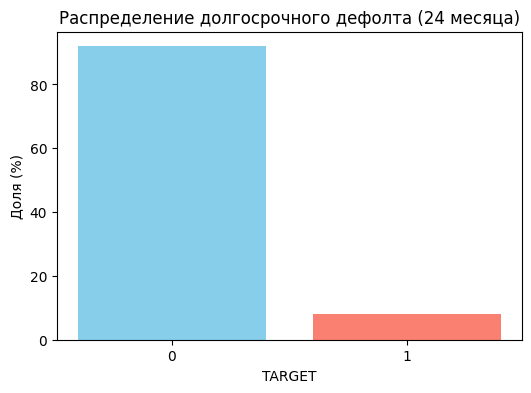


Колонки, содержащие 'DAYS' (всего 5):
['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df_app = pd.read_csv('/Users/eugene/Documents/МФТИ/Диплом/home-credit-default-risk/application_train.csv')

# Размер таблицы
print(f"Размер application_train.csv: {df_app.shape[0]} строк, {df_app.shape[1]} столбцов")

# Первые строки
print("\nПервые 5 строк:")
print(df_app.head())

# Распределение целевой переменной
print("\nРаспределение TARGET:")
target_counts = df_app['TARGET'].value_counts(normalize=True)
print(target_counts)

# Визуализация распределения с помощью matplotlib
plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values * 100, color=['skyblue', 'salmon'])
plt.xlabel('TARGET')
plt.ylabel('Доля (%)')
plt.title('Распределение долгосрочного дефолта (24 месяца)')
plt.show()

# Поиск временных колонок
date_cols = [col for col in df_app.columns if 'DAYS' in col]
print(f"\nКолонки, содержащие 'DAYS' (всего {len(date_cols)}):")
print(date_cols[:10])  # покажем первые 10